# Predicting food demand at KU Mensa

## Data Collection and Preprocessing

This section describes the process of collecting, cleaning, and merging raw Excel files from the KU Mensa system.

We worked with two different data sources:
- **Produktionsplanung** (production planning): contains planned dishes, target portions, and dish descriptions for each day.
- **Verkaufszahlen** (sales data): contains the actual number of portions sold each day, divided into individually sold items and daily menus labeled as Essen 1, 2, etc.

Important:
- The Excel files had inconsistent formats, missing columns, and irregular positioning of cells.
- Dishes in the sales data were listed as "Essen", requiring cross-referencing with production planning to retrieve full descriptions.



In [204]:
import pandas as pd
import glob
import re

In [205]:
path = 'data/'

In [206]:
prod_files = glob.glob(f"{path}/*Produktionsplanung.xlsx")
prod_dfs = []

In [207]:
for file in prod_files:
    df = pd.read_excel(file)
    
    # leave only the necessary columns (the names are in German and in all files are the same)
    df_reduced = df[['Prod.Dat.', 'Gebinde', 'Bezeichnung', 'Sollmenge', 'Ausgabe']]
    
    # remame for convenience
    df_reduced.columns = ['date', 'gebinde', 'dish_name', 'target_amount', 'output']
    
    # adding it to the dataframelist
    prod_dfs.append(df_reduced)

In [208]:
prod_df = pd.concat(prod_dfs, ignore_index=True)

In [209]:
prod_df.head(10)

,date,gebinde,dish_name,target_amount,output
0,2014-01-07,Reis,Butterreis,15,15
1,2014-01-07,Kartoffeln,"Kartoffeln, geschält",3,3
2,2014-01-07,Kartoffelsalat,Kartoffelsalat fertig,80,80
3,2014-01-07,Nudeln,Nudeln Fusilli,0,0
4,2014-01-07,Spätzle,"Spätzle, frisch",0,0
5,2014-01-07,Essen 1 Mensen VK,Hacklett - Hacksteak,162,162
6,2014-01-07,Essen 2 Mensen VK,Puten Cordon Bleu mit Zitrone,240,240
7,2014-01-07,Essen 3 Mensen VK,Pasta mit Tomate-Gemüsesoße,190,190
8,2014-01-07,Pommes frites,Pommes-Frites,200,200
9,2014-01-08,Reis,Butterreis,10,10


In [210]:
prod_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16254 entries, 0 to 16253
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           16254 non-null  datetime64[ns]
 1   gebinde        15810 non-null  object        
 2   dish_name      16254 non-null  object        
 3   target_amount  16254 non-null  int64         
 4   output         16254 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 635.0+ KB


In [211]:
prod_df['date'] = pd.to_datetime(prod_df['date'], format='%d/%m/%Y')

In [212]:
prod_df.head(10)

,date,gebinde,dish_name,target_amount,output
0,2014-01-07,Reis,Butterreis,15,15
1,2014-01-07,Kartoffeln,"Kartoffeln, geschält",3,3
2,2014-01-07,Kartoffelsalat,Kartoffelsalat fertig,80,80
3,2014-01-07,Nudeln,Nudeln Fusilli,0,0
4,2014-01-07,Spätzle,"Spätzle, frisch",0,0
5,2014-01-07,Essen 1 Mensen VK,Hacklett - Hacksteak,162,162
6,2014-01-07,Essen 2 Mensen VK,Puten Cordon Bleu mit Zitrone,240,240
7,2014-01-07,Essen 3 Mensen VK,Pasta mit Tomate-Gemüsesoße,190,190
8,2014-01-07,Pommes frites,Pommes-Frites,200,200
9,2014-01-08,Reis,Butterreis,10,10


In [213]:
prod_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16254 entries, 0 to 16253
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           16254 non-null  datetime64[ns]
 1   gebinde        15810 non-null  object        
 2   dish_name      16254 non-null  object        
 3   target_amount  16254 non-null  int64         
 4   output         16254 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 635.0+ KB


In [214]:
prod_df.head(20)

,date,gebinde,dish_name,target_amount,output
0,2014-01-07,Reis,Butterreis,15,15
1,2014-01-07,Kartoffeln,"Kartoffeln, geschält",3,3
2,2014-01-07,Kartoffelsalat,Kartoffelsalat fertig,80,80
3,2014-01-07,Nudeln,Nudeln Fusilli,0,0
4,2014-01-07,Spätzle,"Spätzle, frisch",0,0
5,2014-01-07,Essen 1 Mensen VK,Hacklett - Hacksteak,162,162
6,2014-01-07,Essen 2 Mensen VK,Puten Cordon Bleu mit Zitrone,240,240
7,2014-01-07,Essen 3 Mensen VK,Pasta mit Tomate-Gemüsesoße,190,190
8,2014-01-07,Pommes frites,Pommes-Frites,200,200
9,2014-01-08,Reis,Butterreis,10,10


In [215]:
# Sollmenge = 0
print(f"Total rows in all Produktionsplanung: {len(prod_df)}")

total_target_zero = (prod_df['target_amount'] == 0).sum()
print(f"Total rows in prod_df with target_amount=0: {total_target_zero}")

print(f'The proportion of such lines: {total_target_zero / len(prod_df):.2%}')

Total rows in all Produktionsplanung: 16254
Total rows in prod_df with target_amount=0: 2930
The proportion of such lines: 18.03%


In [216]:
verkaufs_files = glob.glob('data/*Verkaufszahlen.xlsx')

verkaufs_dfs = []

for file in verkaufs_files:
    df = pd.read_excel(file, header=None)

    # === 1. Read dates ===
    # row 4 (index 3), starting from column I (index 8)
    date_row = df.loc[3, 8:]  

    # Take only non-empty dates
    valid_date_cols = date_row[date_row.notna()]
    
    # Convert to dictionary: {column: date}
    date_map = valid_date_cols.to_dict()

    # === 2. Read dish names ===
    # Column G (index = 6), starting from a certain row (e.g., row 5)
    row_idx = 5 
    while row_idx < len(df):
        dish = df.loc[row_idx, 6] 
        if pd.isna(dish):  
            row_idx += 1
            continue  
        # === 3. Read sales for each date ===
        for col_idx, raw_date in date_map.items():
            sold = df.loc[row_idx, col_idx]
            if pd.notna(sold):
                verkaufs_dfs.append({
                    'dish_name': dish,
                    'date': pd.to_datetime(raw_date, format='%Y.%m.%d', errors='coerce'),
                    'sold_amount': sold
                })
        row_idx += 1  

verkauf_df = pd.DataFrame(verkaufs_dfs)

# Filter out invalid dates (for example, if there was "Gesamt" somewhere)
verkauf_df = verkauf_df[verkauf_df['date'].notna()]
verkauf_df = verkauf_df.sort_values('date').reset_index(drop=True)

print(verkauf_df.head())


                         dish_name       date  sold_amount
0                   Kartoffelsalat 2014-01-07           74
1                             Reis 2014-01-07           15
2                       Kartoffeln 2014-01-07            3
3  Essen- Soziales ohne Berechnung 2014-01-07            1
4                    Pommes frites 2014-01-07          187


In [217]:
verkauf_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13114 entries, 0 to 13113
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   dish_name    13114 non-null  object        
 1   date         13114 non-null  datetime64[ns]
 2   sold_amount  13114 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 307.5+ KB


In [218]:
verkauf_df[verkauf_df['date'] == pd.Timestamp('2015-02-12')]

,dish_name,date,sold_amount
1877,Essen 5,2015-02-12,72
1878,Essen 1,2015-02-12,82
1879,Reis,2015-02-12,5
1880,Kartoffelkloss 200g,2015-02-12,8
1881,Pommes frites,2015-02-12,19
1882,Essen- Soziales ohne Berechnung,2015-02-12,1
1883,Nudeln,2015-02-12,8
1884,Essen 4,2015-02-12,33


In [219]:
prod_df[prod_df['date'] == pd.Timestamp('2015-02-12')]

,date,gebinde,dish_name,target_amount,output
2195,2015-02-12,Reis,Butterreis,15,15
2196,2015-02-12,Kloß 200 gr,"Kloß, 200g",8,8
2197,2015-02-12,Nudeln,Nudeln Spirelli,20,20
2198,2015-02-12,NaN,Kräuterbraten v.Schwein m. Kloß u. Rotk,191,191
2199,2015-02-12,Essen 4 Mensen VK,Kartoffel-Broccoli-Flan,40,40
2200,2015-02-12,Essen 5 Mensen VK,Thai- Wraps mit Chilli-Ingwer-Dip- Vegan,76,76
2201,2015-02-12,Pommes frites,Pommes-Frites,19,19


### Preliminary observations

We have collected data from two different sources:

- `prod_df`: contains information from all *Produktionsplanung* (production planning) Excel files, including planned and actual quantities (`Sollmenge`, `Ausgabe`).
- `verkauf_df`: contains sales data extracted from *Verkaufszahlen* files, representing the actual number of dishes sold per day.

Although the `Ausgabe` column in `prod_df` is meant to reflect the actual number of dishes distributed, it **does not always match** the corresponding sales values found in `verkauf_df`. This discrepancy is likely due to differences in data collection or reporting logic between the two sources.

**Conclusion:**  
For the remainder of the analysis, we will **rely on the data from `verkauf_df`** as the ground truth for the number of dishes sold, since it provides a more accurate and consistent daily breakdown of sales.

In [220]:
verkauf_df[verkauf_df['date'] == pd.Timestamp('2020-06-16')]

,dish_name,date,sold_amount
9542,Essen 4,2020-06-16,55
9543,Pizza veget./vegan,2020-06-16,7
9544,Essen 1,2020-06-16,37
9545,Pizza Fleisch/Fisch,2020-06-16,9


In [221]:
prod_df[prod_df['date'] == pd.Timestamp('2020-06-16')]

,date,gebinde,dish_name,target_amount,output
10785,2020-06-16,Essen 1 Mensen VK,Bratwürste - Fränkische Art,37,37
10786,2020-06-16,Essen 4 Mensen VK,Pasta mit Tomaten-Chilipesto und frische,0,55
10787,2020-06-16,Pizza Fleisch/Fisch,EP - Pizza Speziale,25,9
10788,2020-06-16,Kartoffeln,"Kartoffeln, gar",0,0
10789,2020-06-16,Reis,Reis,5,0
10790,2020-06-16,Pizza vegetarisch/vegan,EP - Pizza Margherita,36,7


In [222]:
# Function to extract "Essen X" from a string
def extract_essen(gebinde):
    if isinstance(gebinde, str):
        match = re.match(r'(Essen\s\d)', gebinde)
        if match:
            return match.group(1)  # return only "Essen 1"
    return gebinde  # if not Essen — return as is

# Apply to prod_df
prod_df['gebinde_clean'] = prod_df['gebinde'].apply(extract_essen)

In [223]:
prod_df.head(10)

,date,gebinde,dish_name,target_amount,output,gebinde_clean
0,2014-01-07,Reis,Butterreis,15,15,Reis
1,2014-01-07,Kartoffeln,"Kartoffeln, geschält",3,3,Kartoffeln
2,2014-01-07,Kartoffelsalat,Kartoffelsalat fertig,80,80,Kartoffelsalat
3,2014-01-07,Nudeln,Nudeln Fusilli,0,0,Nudeln
4,2014-01-07,Spätzle,"Spätzle, frisch",0,0,Spätzle
5,2014-01-07,Essen 1 Mensen VK,Hacklett - Hacksteak,162,162,Essen 1
6,2014-01-07,Essen 2 Mensen VK,Puten Cordon Bleu mit Zitrone,240,240,Essen 2
7,2014-01-07,Essen 3 Mensen VK,Pasta mit Tomate-Gemüsesoße,190,190,Essen 3
8,2014-01-07,Pommes frites,Pommes-Frites,200,200,Pommes frites
9,2014-01-08,Reis,Butterreis,10,10,Reis


In [224]:
# Merge by date and "Essen"
verkauf_df_enriched = verkauf_df.merge(
    prod_df[['date', 'gebinde_clean', 'dish_name', 'target_amount']],
    left_on=['date', 'dish_name'],
    right_on=['date', 'gebinde_clean'],
    how='left'
)

# Create the final column: use the real dish name if found, otherwise keep the original
verkauf_df_enriched['final_dish_name'] = verkauf_df_enriched['dish_name_y'].combine_first(verkauf_df_enriched['dish_name_x'])

# Remove unnecessary columns
verkauf_df_enriched = verkauf_df_enriched[['date', 'dish_name_x', 'target_amount', 'sold_amount', 'final_dish_name']]
verkauf_df_enriched.columns = ['date', 'original_name', 'target_amount', 'sold_amount', 'dish_name']


In [225]:
verkauf_df_enriched.head()

,date,original_name,target_amount,sold_amount,dish_name
0,2014-01-07,Kartoffelsalat,80.0,74,Kartoffelsalat fertig
1,2014-01-07,Reis,15.0,15,Butterreis
2,2014-01-07,Kartoffeln,3.0,3,"Kartoffeln, geschält"
3,2014-01-07,Essen- Soziales ohne Berechnung,NaN,1,Essen- Soziales ohne Berechnung
4,2014-01-07,Pommes frites,200.0,187,Pommes-Frites


In [226]:
verkauf_df_enriched.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13132 entries, 0 to 13131
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           13132 non-null  datetime64[ns]
 1   original_name  13132 non-null  object        
 2   target_amount  11759 non-null  float64       
 3   sold_amount    13132 non-null  int64         
 4   dish_name      13132 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 513.1+ KB


In some cases, the 'target_amount' (i.e., the planned number of portions) is missing 
because the dish was not listed in the production planning files.
However, since we have the actual 'sold_amount' from the sales data,
we use it as a fallback estimate for the missing target.
This allows the model to have a reasonable value instead of NaN 
and prevents loss of useful training data.


In [227]:

verkauf_df_enriched['target_amount'] = verkauf_df_enriched['target_amount'].fillna(verkauf_df_enriched['sold_amount'])

In [228]:
verkauf_df_enriched.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13132 entries, 0 to 13131
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           13132 non-null  datetime64[ns]
 1   original_name  13132 non-null  object        
 2   target_amount  13132 non-null  float64       
 3   sold_amount    13132 non-null  int64         
 4   dish_name      13132 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 513.1+ KB


In [229]:
verkauf_df_enriched.head(10)

,date,original_name,target_amount,sold_amount,dish_name
0,2014-01-07,Kartoffelsalat,80.0,74,Kartoffelsalat fertig
1,2014-01-07,Reis,15.0,15,Butterreis
2,2014-01-07,Kartoffeln,3.0,3,"Kartoffeln, geschält"
3,2014-01-07,Essen- Soziales ohne Berechnung,1.0,1,Essen- Soziales ohne Berechnung
4,2014-01-07,Pommes frites,200.0,187,Pommes-Frites
5,2014-01-07,Essen 3,190.0,185,Pasta mit Tomate-Gemüsesoße
6,2014-01-07,Essen 2,240.0,237,Puten Cordon Bleu mit Zitrone
7,2014-01-07,Essen 1,162.0,159,Hacklett - Hacksteak
8,2014-01-08,Röstkartoffeln,34.0,34,Röstkartoffeln (EH)
9,2014-01-08,Nudeln,1.0,1,Nudeln Fusilli


## Visualization

### 1. The most popular dishes
The goal: to find out which dishes were sold most often

⚠️ Note: This visualization is not fully accurate yet. 
Some dishes appear multiple times with different names. 
It will be improved later using LLM to group similar dish names together.


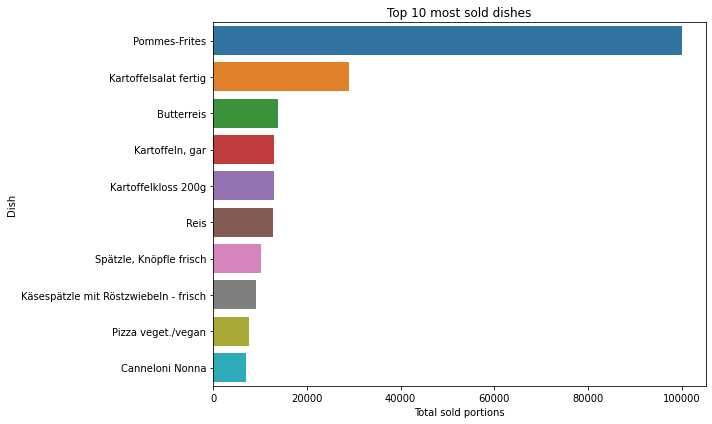

In [234]:
import matplotlib.pyplot as plt
import seaborn as sns

top_dishes = verkauf_df_enriched.groupby('dish_name')['sold_amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_dishes.values, y=top_dishes.index)
plt.title('Top 10 most sold dishes')
plt.xlabel('Total sold portions')
plt.ylabel('Dish')
plt.tight_layout()
plt.show()

### 2. Sales by day of the week
Goal: to understand which days of the week have the most sales

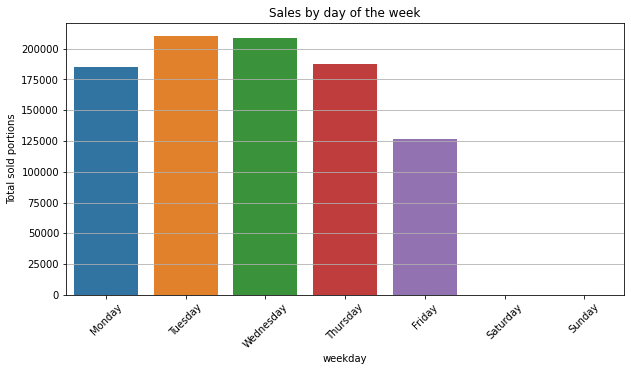

In [235]:
verkauf_df_enriched['weekday'] = pd.to_datetime(verkauf_df_enriched['date']).dt.day_name()

weekday_sales = verkauf_df_enriched.groupby('weekday')['sold_amount'].sum().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])

plt.figure(figsize=(10, 5))
sns.barplot(x=weekday_sales.index, y=weekday_sales.values)
plt.title('Sales by day of the week')
plt.ylabel('Total sold portions')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


### 3. Sales by day of the week (per year)

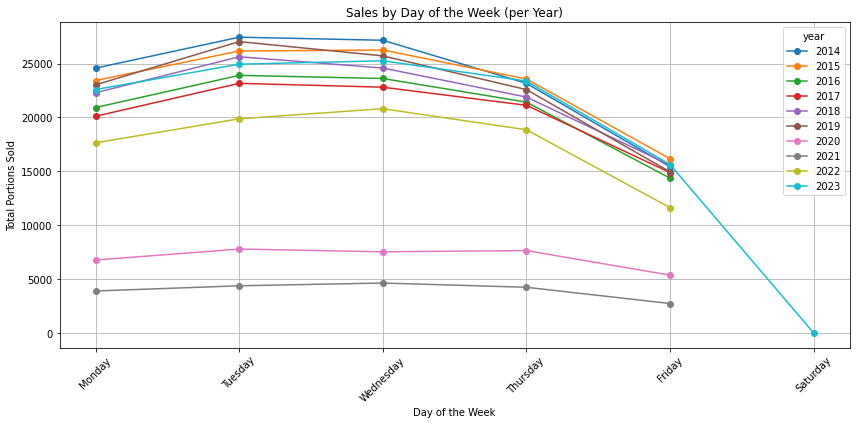

In [242]:
verkauf_df_enriched['year'] = verkauf_df_enriched['date'].dt.year
verkauf_df_enriched['weekday'] = verkauf_df_enriched['date'].dt.day_name()

grouped = (
    verkauf_df_enriched
    .groupby(['year', 'weekday'])['sold_amount']
    .sum()
    .reset_index()
)

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
grouped['weekday'] = pd.Categorical(grouped['weekday'], categories=weekday_order, ordered=True)
grouped = grouped.sort_values(['year', 'weekday'])

pivot = grouped.pivot(index='weekday', columns='year', values='sold_amount')
pivot = pivot.reindex(weekday_order) 

pivot.plot(kind='line', marker='o', figsize=(12, 6))
plt.title('Sales by Day of the Week (per Year)')
plt.xlabel('Day of the Week')
plt.ylabel('Total Portions Sold')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4. Comparison of Essen vs. Single Dishes
Goal: Compare total sales of Essen menus and individually sold dishes.
This helps to understand how the demand for different meal types varies by year or day of the week.

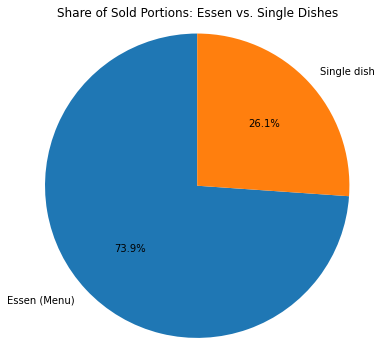

In [248]:
type_summary = verkauf_df_enriched.groupby('dish_type')['sold_amount'].sum()

plt.figure(figsize=(6, 6))
plt.pie(type_summary, labels=type_summary.index, autopct='%1.1f%%', startangle=90)
plt.title('Share of Sold Portions: Essen vs. Single Dishes')
plt.axis('equal') 
plt.show()


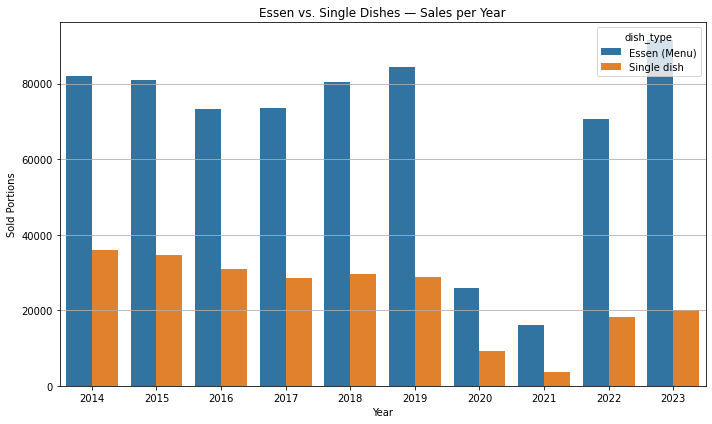

In [246]:
verkauf_df_enriched['year'] = verkauf_df_enriched['date'].dt.year
grouped_by_year = verkauf_df_enriched.groupby(['year', 'dish_type'])['sold_amount'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=grouped_by_year, x='year', y='sold_amount', hue='dish_type')
plt.title('Essen vs. Single Dishes — Sales per Year')
plt.ylabel('Sold Portions')
plt.xlabel('Year')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

The next analysis is based on 2018 data only.

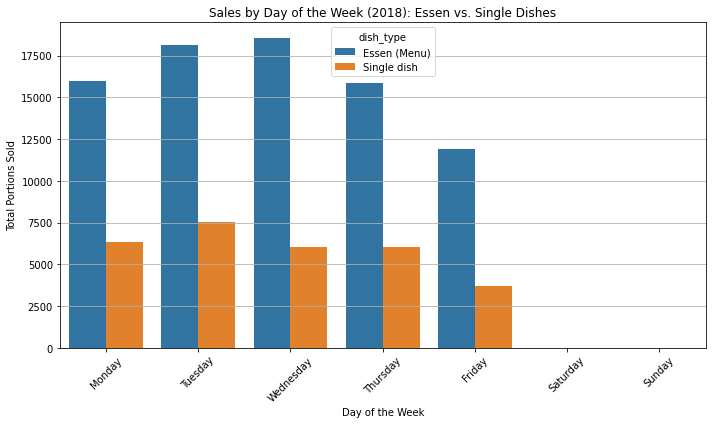

In [251]:
verkauf_df_enriched['year'] = verkauf_df_enriched['date'].dt.year
verkauf_df_enriched['weekday'] = verkauf_df_enriched['date'].dt.day_name()

df_2018 = verkauf_df_enriched[verkauf_df_enriched['year'] == 2018]

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
grouped = (
    df_2018
    .groupby(['dish_type', 'weekday'])['sold_amount']
    .sum()
    .reset_index()
)
grouped['weekday'] = pd.Categorical(grouped['weekday'], categories=weekday_order, ordered=True)
grouped = grouped.sort_values(['weekday', 'dish_type'])

plt.figure(figsize=(10, 6))
sns.barplot(data=grouped, x='weekday', y='sold_amount', hue='dish_type')
plt.title('Sales by Day of the Week (2018): Essen vs. Single Dishes')
plt.xlabel('Day of the Week')
plt.ylabel('Total Portions Sold')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


### 5. Some more visualisations
Goal: to get a better understanding of data (is it "seasoned", what about sales in COVID-Period, lecture-free periods etc.)

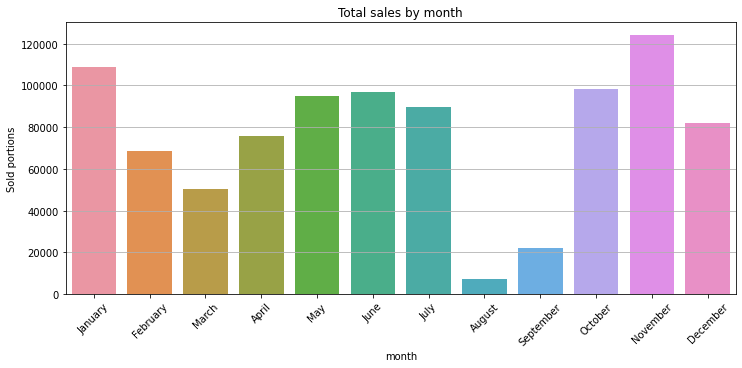

In [240]:
verkauf_df_enriched['month'] = pd.to_datetime(verkauf_df_enriched['date']).dt.month_name()

monthly_sales = verkauf_df_enriched.groupby('month')['sold_amount'].sum().reindex([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])

plt.figure(figsize=(12, 5))
sns.barplot(x=monthly_sales.index, y=monthly_sales.values)
plt.title('Total sales by month')
plt.ylabel('Sold portions')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

How popular is a dish overall

⚠️ Note: This visualization is not fully accurate yet. 
It will be improved later using LLM to group similar dish names together.

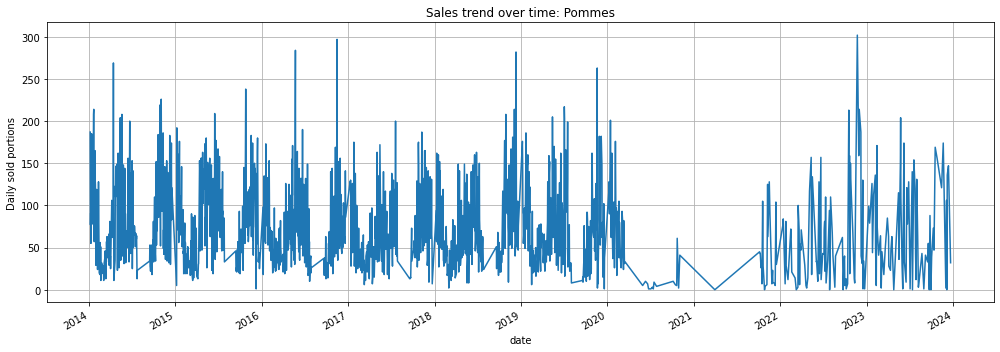

In [ ]:
dish_name = 'Pommes'
df = verkauf_df_enriched[verkauf_df_enriched['dish_name'].str.contains(dish_name, case=False, na=False)]

daily_sales = df.groupby('date')['sold_amount'].sum()

plt.figure(figsize=(14, 5))
daily_sales.plot()
plt.title(f'Sales trend over time: {dish_name}')
plt.ylabel('Daily sold portions')
plt.grid()
plt.tight_layout()
plt.show()

Top 5 popular dishes plotted

⚠️ Note: This visualization is not fully accurate yet. 
It will be improved later using LLM to group similar dish names together.

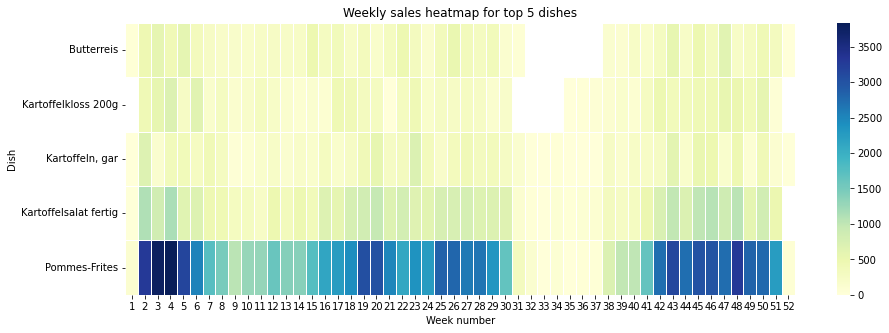

In [244]:
verkauf_df_enriched['week'] = verkauf_df_enriched['date'].dt.isocalendar().week

# Top 5 popular dishes plotted
top5_dishes = verkauf_df_enriched.groupby('dish_name')['sold_amount'].sum().sort_values(ascending=False).head(5).index

heatmap_data = verkauf_df_enriched[verkauf_df_enriched['dish_name'].isin(top5_dishes)]
heatmap_pivot = heatmap_data.pivot_table(index='dish_name', columns='week', values='sold_amount', aggfunc='sum')

plt.figure(figsize=(15, 5))
sns.heatmap(heatmap_pivot, cmap='YlGnBu', linewidths=0.5)
plt.title('Weekly sales heatmap for top 5 dishes')
plt.xlabel('Week number')
plt.ylabel('Dish')
plt.show()

## Feature Engineering

In [252]:
verkauf_df_enriched['date'] = pd.to_datetime(verkauf_df_enriched['date'])

#Time features
verkauf_df_enriched['year'] = verkauf_df_enriched['date'].dt.year
verkauf_df_enriched['month'] = verkauf_df_enriched['date'].dt.month#1–12
verkauf_df_enriched['day'] = verkauf_df_enriched['date'].dt.day#1–31
verkauf_df_enriched['weekday'] = verkauf_df_enriched['date'].dt.weekday  # 0 = monday
verkauf_df_enriched['is_weekend'] = verkauf_df_enriched['weekday'].isin([5, 6]).astype(int)#1-weekend, 0-no
verkauf_df_enriched['weekofyear'] = verkauf_df_enriched['date'].dt.isocalendar().week#week in year number
verkauf_df_enriched[['date', 'year', 'month', 'day', 'weekday', 'is_weekend', 'weekofyear']].head()

,date,year,month,day,weekday,is_weekend,weekofyear
0,2014-01-07,2014,1,7,1,0,2
1,2014-01-07,2014,1,7,1,0,2
2,2014-01-07,2014,1,7,1,0,2
3,2014-01-07,2014,1,7,1,0,2
4,2014-01-07,2014,1,7,1,0,2


### Rolling Features

To capture temporal trends and short-term seasonality in dish sales, we created **rolling average** and **rolling median** features.

For each dish, we computed:

- **7-day rolling mean and median** of `sold_amount` and `target_amount`
- **30-day rolling mean and median** of `sold_amount` and `target_amount`

These features summarize the recent sales and planning history (excluding the current day via `.shift(1)`), allowing the model to learn from past behavior.

This approach helps improve predictions, especially for frequently repeated dishes.


- Week (short trend)

In [253]:
# sort by date
# verkauf_df_enriched = verkauf_df_enriched.sort_values(['original_name', 'date'])

# sold_amount- mean for 7 days, if no histiry/mew dish-NaN
verkauf_df_enriched['rolling_7d_sold_mean'] = (
    verkauf_df_enriched.groupby('original_name')['sold_amount']
    .transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).mean())
)

# 7 day median sales
verkauf_df_enriched['rolling_7d_sold_median'] = (
    verkauf_df_enriched.groupby('dish_name')['sold_amount']
    .transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).median())
)
# 7 day mean target
verkauf_df_enriched['rolling_7d_target_mean'] = (
    verkauf_df_enriched.groupby('original_name')['target_amount']
    .transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).mean())
)
# 7 day median target
verkauf_df_enriched['rolling_7d_target_median'] = (
    verkauf_df_enriched.groupby('dish_name')['target_amount']
    .transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).median())
)
verkauf_df_enriched[['date', 'original_name', 'sold_amount', 'rolling_7d_sold_mean','rolling_7d_sold_median','rolling_7d_target_mean','rolling_7d_target_median']].tail(20)

,date,original_name,sold_amount,rolling_7d_sold_mean,rolling_7d_sold_median,rolling_7d_target_mean,rolling_7d_target_median
13112,2023-12-18,Essen 4,208,201.571429,226.0,185.714286,231.0
13113,2023-12-18,Essen 1,70,146.142857,95.0,145.714286,120.0
13114,2023-12-18,Reis,5,4.285714,3.0,4.285714,3.0
13115,2023-12-18,Essen freier Preis,1,5.857143,6.0,5.857143,6.0
13116,2023-12-19,Reis,4,4.857143,4.0,4.857143,4.0
13117,2023-12-19,Essen freier Preis,33,5.000000,5.0,5.000000,5.0
13118,2023-12-19,Essen 5,252,186.000000,301.0,223.142857,180.0
13119,2023-12-19,Essen 4,89,204.571429,59.5,181.428571,60.5
13120,2023-12-19,Essen 1,164,140.714286,NaN,140.000000,NaN
13121,2023-12-20,Essen freier Preis,3,8.000000,5.0,8.000000,5.0


It is better to replace dish_name and original_name with one single normalized feature when the LLM is ready.

- Month (long trend)

In [257]:
# 30 days mean  (no info-Nan)
verkauf_df_enriched['rolling_30d_sold_mean'] = (
    verkauf_df_enriched.groupby('dish_name')['sold_amount']
    .transform(lambda x: x.shift(1).rolling(window=30, min_periods=1).mean())
)


# 30 days median (no info-Nan)
verkauf_df_enriched['rolling_30d_sold_median'] = (
    verkauf_df_enriched.groupby('dish_name')['sold_amount']
    .transform(lambda x: x.shift(1).rolling(window=30, min_periods=1).median())
)
# 30 days mean  (no info-Nan)
verkauf_df_enriched['rolling_30d_target_mean'] = (
    verkauf_df_enriched.groupby('dish_name')['target_amount']
    .transform(lambda x: x.shift(1).rolling(window=30, min_periods=1).mean())
)


# 30 days median (no info-Nan)
verkauf_df_enriched['rolling_30d_target_median'] = (
    verkauf_df_enriched.groupby('dish_name')['target_amount']
    .transform(lambda x: x.shift(1).rolling(window=30, min_periods=1).median())
)
verkauf_df_enriched[['date', 'original_name', 'sold_amount', 'rolling_30d_sold_mean','rolling_30d_sold_median','rolling_30d_target_mean','rolling_30d_target_median']].tail()

,date,original_name,sold_amount,rolling_30d_sold_mean,rolling_30d_sold_median,rolling_30d_target_mean,rolling_30d_target_median
13127,2023-12-21,Essen 4,167,132.000000,132.0,133.000000,133.0
13128,2023-12-21,Pommes frites,32,61.600000,43.0,57.900000,42.5
13129,2023-12-21,Kartoffelsalat,4,32.866667,21.5,37.900000,22.0
13130,2023-12-21,Essen 1,115,116.545455,86.0,119.818182,90.0
13131,2023-12-22,Essen freier Preis,13,6.900000,4.5,6.900000,4.5


In [256]:
verkauf_df_enriched.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13132 entries, 0 to 13131
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       13132 non-null  datetime64[ns]
 1   original_name              13132 non-null  object        
 2   target_amount              13132 non-null  float64       
 3   sold_amount                13132 non-null  int64         
 4   dish_name                  13132 non-null  object        
 5   weekday                    13132 non-null  int32         
 6   year                       13132 non-null  int32         
 7   month                      13132 non-null  int32         
 8   week                       13132 non-null  UInt32        
 9   dish_type                  13132 non-null  object        
 10  day                        13132 non-null  int32         
 11  is_weekend                 13132 non-null  int32         
 12  week

### Handling Missing Values in Rolling Features

The rolling statistics (mean/median over 7 and 30 days) contain missing values at the beginning of each dish's sales history, because there is not enough past data for the rolling window.

To avoid losing useful rows during modeling, we fill these missing values with the mean of each corresponding column. This provides a reasonable estimate and allows the model to still benefit from the rolling features, especially when history is short.


In [258]:
rolling_cols = [col for col in verkauf_df_enriched.columns if 'rolling_' in col]
verkauf_df_enriched[rolling_cols] = verkauf_df_enriched[rolling_cols].fillna(verkauf_df_enriched[rolling_cols].mean())


In [259]:
verkauf_df_enriched.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13132 entries, 0 to 13131
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       13132 non-null  datetime64[ns]
 1   original_name              13132 non-null  object        
 2   target_amount              13132 non-null  float64       
 3   sold_amount                13132 non-null  int64         
 4   dish_name                  13132 non-null  object        
 5   weekday                    13132 non-null  int32         
 6   year                       13132 non-null  int32         
 7   month                      13132 non-null  int32         
 8   week                       13132 non-null  UInt32        
 9   dish_type                  13132 non-null  object        
 10  day                        13132 non-null  int32         
 11  is_weekend                 13132 non-null  int32         
 12  week

Dish frequency:

In [260]:
dish_freq = verkauf_df_enriched['original_name'].value_counts()
verkauf_df_enriched['dish_freq'] = verkauf_df_enriched['original_name'].map(dish_freq)


Essen or Single:

In [261]:
verkauf_df_enriched['is_essen'] = (verkauf_df_enriched['dish_type'] == 'Essen (Menu)').astype(int)


In [262]:
verkauf_df_enriched.head(10)

,date,original_name,target_amount,sold_amount,dish_name,weekday,year,month,week,dish_type,...,rolling_7d_sold_mean,rolling_7d_sold_median,rolling_7d_target_mean,rolling_7d_target_median,rolling_30d_sold_mean,rolling_30d_sold_median,rolling_30d_target_mean,rolling_30d_target_median,dish_freq,is_essen
0,2014-01-07,Kartoffelsalat,80.0,74,Kartoffelsalat fertig,1,2014,1,2,Single dish,...,70.102019,63.182901,73.84814,66.616574,66.668705,62.374719,69.736775,65.690484,945,0
1,2014-01-07,Reis,15.0,15,Butterreis,1,2014,1,2,Single dish,...,70.102019,63.182901,73.84814,66.616574,66.668705,62.374719,69.736775,65.690484,1506,0
2,2014-01-07,Kartoffeln,3.0,3,"Kartoffeln, geschält",1,2014,1,2,Single dish,...,70.102019,63.182901,73.84814,66.616574,66.668705,62.374719,69.736775,65.690484,625,0
3,2014-01-07,Essen- Soziales ohne Berechnung,1.0,1,Essen- Soziales ohne Berechnung,1,2014,1,2,Essen (Menu),...,70.102019,63.182901,73.84814,66.616574,66.668705,62.374719,69.736775,65.690484,192,1
4,2014-01-07,Pommes frites,200.0,187,Pommes-Frites,1,2014,1,2,Single dish,...,70.102019,63.182901,73.84814,66.616574,66.668705,62.374719,69.736775,65.690484,1417,0
5,2014-01-07,Essen 3,190.0,185,Pasta mit Tomate-Gemüsesoße,1,2014,1,2,Essen (Menu),...,70.102019,63.182901,73.84814,66.616574,66.668705,62.374719,69.736775,65.690484,419,1
6,2014-01-07,Essen 2,240.0,237,Puten Cordon Bleu mit Zitrone,1,2014,1,2,Essen (Menu),...,70.102019,63.182901,73.84814,66.616574,66.668705,62.374719,69.736775,65.690484,1304,1
7,2014-01-07,Essen 1,162.0,159,Hacklett - Hacksteak,1,2014,1,2,Essen (Menu),...,70.102019,63.182901,73.84814,66.616574,66.668705,62.374719,69.736775,65.690484,1812,1
8,2014-01-08,Röstkartoffeln,34.0,34,Röstkartoffeln (EH),2,2014,1,2,Single dish,...,70.102019,63.182901,73.84814,66.616574,66.668705,62.374719,69.736775,65.690484,140,0
9,2014-01-08,Nudeln,1.0,1,Nudeln Fusilli,2,2014,1,2,Single dish,...,70.102019,63.182901,73.84814,66.616574,66.668705,62.374719,69.736775,65.690484,511,0


In [263]:
verkauf_df_enriched.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13132 entries, 0 to 13131
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       13132 non-null  datetime64[ns]
 1   original_name              13132 non-null  object        
 2   target_amount              13132 non-null  float64       
 3   sold_amount                13132 non-null  int64         
 4   dish_name                  13132 non-null  object        
 5   weekday                    13132 non-null  int32         
 6   year                       13132 non-null  int32         
 7   month                      13132 non-null  int32         
 8   week                       13132 non-null  UInt32        
 9   dish_type                  13132 non-null  object        
 10  day                        13132 non-null  int32         
 11  is_weekend                 13132 non-null  int32         
 12  week

## Model

### Target Variable

Our goal is to predict the number of sold portions for each dish on a given day.  
Thus, we define **`sold_amount`** as the target variable for our regression task.

This target is continuous and numerical, making this a classic **regression problem**.


In [264]:
y = verkauf_df_enriched['sold_amount']

features = [
    'target_amount', 'year', 'month', 'day', 'weekday', 'is_weekend', 'weekofyear',
    'rolling_7d_sold_mean', 'rolling_7d_sold_median',
    'rolling_7d_target_mean', 'rolling_7d_target_median',
    'rolling_30d_sold_mean', 'rolling_30d_sold_median',
    'rolling_30d_target_mean', 'rolling_30d_target_median',
    'dish_freq', 'is_essen'
]
X = verkauf_df_enriched[features]

### Train/Test Split Strategy

Since we are working with time series data, it is crucial to avoid data leakage by using a chronological split.

We sorted the dataset by date and used the **first 80%** of the observations as the training set, and the **remaining 20%** as the test set.  
This ensures that the model only sees past data when making predictions on the future, simulating a real-world forecasting scenario.


In [265]:
verkauf_df_enriched = verkauf_df_enriched.sort_values('date')

split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]


### Random Forest

In [266]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Model evaluation:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))


Model evaluation:
MAE: 12.207556147696993
R²: 0.8829219272274833


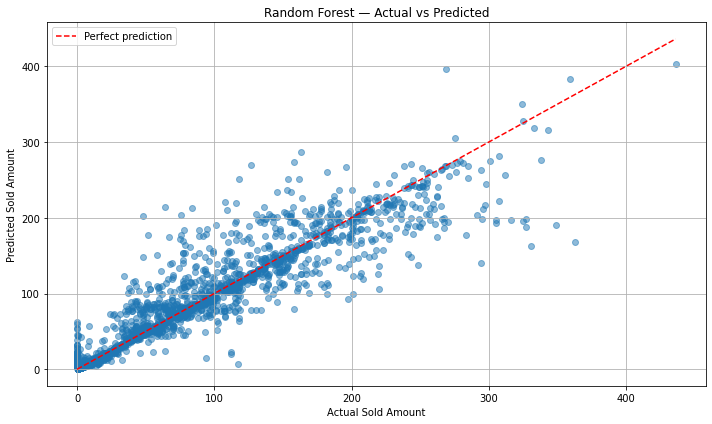

In [267]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', label='Perfect prediction')

plt.xlabel('Actual Sold Amount')
plt.ylabel('Predicted Sold Amount')
plt.title('Random Forest — Actual vs Predicted')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

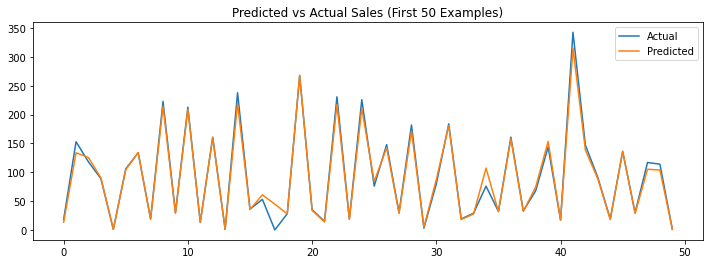

In [269]:
plt.figure(figsize=(12, 4))
plt.plot(y_test.values[:50], label='Actual')
plt.plot(y_pred[:50], label='Predicted')
plt.legend()
plt.title('Predicted vs Actual Sales (First 50 Examples)')
plt.show()

The results showed **strong performance**, with an R² of **0.88** and a MAE of approximately **12.2 portions**.  
The model captures general trends well and performs consistently across a variety of dishes.

### Linear Regression

In [270]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Linear Regression evaluation:")
print("Linear Regression MAE:", mean_absolute_error(y_test, y_pred_lr))
print("Linear Regression R²:", r2_score(y_test, y_pred_lr))


Linear Regression evaluation:
Linear Regression MAE: 11.81648121009023
Linear Regression R²: 0.8934353358871829


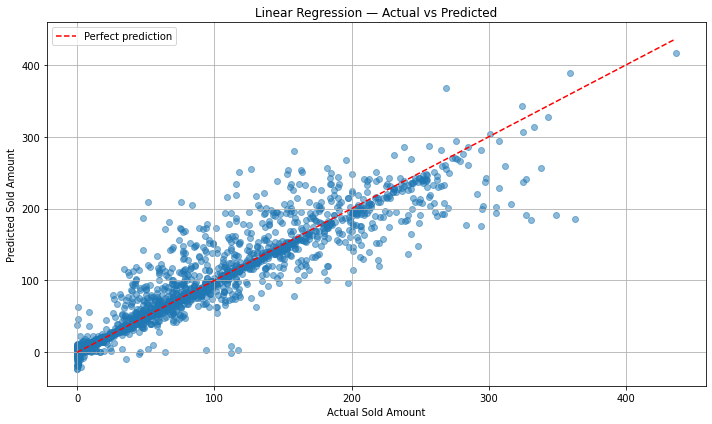

In [271]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', label='Perfect prediction')

plt.xlabel('Actual Sold Amount')
plt.ylabel('Predicted Sold Amount')
plt.title('Linear Regression — Actual vs Predicted')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

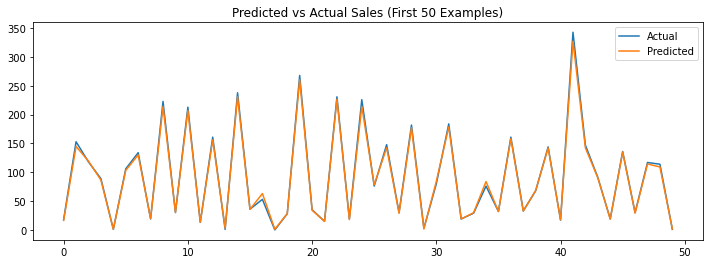

In [272]:
plt.figure(figsize=(12, 4))
plt.plot(y_test.values[:50], label='Actual')
plt.plot(y_pred_lr[:50], label='Predicted')
plt.legend()
plt.title('Predicted vs Actual Sales (First 50 Examples)')
plt.show()

We also trained a simple `LinearRegression` model as a baseline. Surprisingly, it performed slightly better than the random forest.

This suggests that the relationship between our features (e.g., target amount, weekday, rolling averages) and the target is largely linear, or at least well-approximated by a linear model.


### Modeling Results Summary

Both models performed well, with Linear Regression slightly outperforming Random Forest.  
The rolling features (7-day and 30-day history), time-based features, and target planning turned out to be strong predictors.

- Random Forest: R² = 0.88, MAE ≈ 12.2
- Linear Regression: R² = 0.89, MAE ≈ 11.8

This shows that even a simple linear model can be very effective for this problem, though more complex models may be needed in the presence of deeper structure or feature interactions.


## Next Steps and Model Improvements

- **Hyperparameter tuning**: We will apply grid search to further optimize Random Forest and potentially try XGBoost and CatBoost.
- **LLM-based feature engineering**: Many dish names are inconsistent (e.g. "Pommes frites" vs "Pommes-Frites"). We plan to use an LLM-based embedding model to detect and group similar dishes.
- **Holiday or event detection**: External features such as holidays or exam weeks may affect demand and could be added.
- **Evaluation on unseen time periods**: We will test models on different years to validate generalization.

This will help us improve forecasting accuracy and create a more production-ready demand prediction pipeline.
